# Walk Forward Validation Analysis and Model Selection
In this notebook, we explore the results of the walk-forward validation experiment, portfolio performances. Eventually, these are used to selected models that will be passed on to the testing stage on completely unseen data with no look ahead bias.

### Setup:

In [1]:
# All imports
import sys
from pathlib import Path

# Get the absolute path of the directory one level up
root_dir = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import os
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import plotly.graph_objects as go
from src.utils.io import load_path_config
from src.data_processing.loading import load_csv_files, ArtifactDataExtractor
from src.evaluation.selection import filter_models
from sklearn.decomposition import PCA
from src.utils.window import calc_current_idxs, get_date_index_col
from sklearn.preprocessing import StandardScaler
from src.visualization.plots import plot_windowed_comparison, plot_corr, plot_3d_pareto, plot_2d_pareto
from src.evaluation.selection import high_corr_with_each_metric, pareto_dominance
from src.utils.constants import EQ_WT_NAME, SP500_NAME

from src.models.registry import TradModelLibrary, NNModelLibrary

In [2]:
paths_config = load_path_config(os.path.join('../config', 'paths.json'))

# Convert str paths to Path
artifacts_paths = {}
for name, path in paths_config['artifacts'].items():
    dir_path = Path('../'+ path)
    artifacts_paths[name] = dir_path

TradModelLibrary.autodiscover('src.models')
# Registering all NN models to the library
NNModelLibrary.autodiscover('src.models') # MUST be executed for model registration

In [3]:

grid_mode = 'one_model'
model_name = None
loss_name = None # Change previous grid mode if needed

extractor = ArtifactDataExtractor(grid_mode, artifacts_paths)

if grid_mode == 'one_model':
    # Get all models from library
    all_models = []
    for cat in NNModelLibrary.list_categories():
        all_models.extend(NNModelLibrary.list_models(cat))

    all_avg_perf = extractor.agg_avg_perf('avg_perf', all_models)
    opti_hparams = extractor.agg_opti_hparams('optimized', all_models)
    all_daily_rets = extractor.agg_daily_rets('daily_rets', all_models)

    #### Remove custom losses 13 and 14 ####
    # mask = all_avg_perf.index.str.contains('-custom_loss_13|-custom_loss_14')
    # all_avg_perf = all_avg_perf[~mask]
    
elif grid_mode == 'one' and model_name is not None and loss_name is not None:
    opti_hparams = extractor.agg_opti_hparams(
        'optimized', [f'{model_name}-{loss_name}']
    )
    filtered_models = None

In [4]:
# all_benches = TradModelLibrary.list_models()
all_benches = [EQ_WT_NAME, SP500_NAME]

# Filter models that beat Equal Weight Portfolio
filtered_perf, filtered_models = filter_models(
    all_avg_perf, EQ_WT_NAME, 'sharpe', all_benches
)

print(f'\n {len(filtered_models)} Models beat Equal Weight portfolio.')
# print('Filtered Avg. Performance Metrics: \n', filtered_perf)
filtered_perf = filtered_perf.sort_values(by='sharpe', ascending=False)
filtered_perf


 12 Models beat Equal Weight portfolio.


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
TemporalTransformer-custom_loss_11,0.116925,0.136675,0.213725,-0.107150,-0.038087,1.477050,0.031200
DeformTime-custom_loss_14,0.082600,0.123362,0.186925,-0.093062,-0.032987,1.409587,0.024675
AttentionLSTM-custom_loss_11,0.086675,0.119913,0.198362,-0.094225,-0.033962,1.414625,0.030087
TemporalTransformer-custom_loss_13,0.075537,0.111925,0.174750,-0.100487,-0.032837,1.379350,0.023100
VLSTM-custom_loss_13,0.075612,0.111113,0.173775,-0.096287,-0.031837,1.373175,0.023175
InvertedAttentionLSTM-custom_loss_14,0.067587,0.110850,0.154025,-0.108400,-0.033150,1.371637,0.019100
BaseLSTM-custom_loss_11,0.070775,0.109987,0.165675,-0.101325,-0.035300,1.375188,0.022100
TemporalTransformer-custom_loss_14,0.085938,0.109600,0.159762,-0.110762,-0.038087,1.384888,0.024938
AttentionLSTM-custom_loss_14,0.056700,0.109262,0.167687,-0.096537,-0.031675,1.381212,0.023050
PatchTST-custom_loss_14,0.057100,0.107900,0.164350,-0.095675,-0.031813,1.374525,0.022613


In [5]:
all_avg_perf

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
DeformTime-custom_loss_10,0.044362,0.080825,0.126800,-0.120688,-0.039663,1.275038,0.020375
DeformTime-custom_loss_11,0.121750,0.105137,0.216938,-0.187150,-0.059487,1.466938,0.032500
DeformTime-custom_loss_13,0.060812,0.089362,0.134900,-0.102975,-0.036937,1.295725,0.018625
DeformTime-custom_loss_14,0.082600,0.123362,0.186925,-0.093062,-0.032987,1.409587,0.024675
Equal_Weight,0.056287,0.107725,0.163887,-0.095925,-0.031587,1.374600,0.022575
S&P500,0.049075,0.104487,0.139950,-0.092262,-0.032350,1.343400,0.020125
TemporalTransformer-custom_loss_10,0.056900,0.102112,0.158887,-0.096875,-0.032975,1.348688,0.021862
TemporalTransformer-custom_loss_11,0.116925,0.136675,0.213725,-0.107150,-0.038087,1.477050,0.031200
TemporalTransformer-custom_loss_13,0.075537,0.111925,0.174750,-0.100487,-0.032837,1.379350,0.023100
TemporalTransformer-custom_loss_14,0.085938,0.109600,0.159762,-0.110762,-0.038087,1.384888,0.024938


## Mean Sharpe Analysis
### Overall View

Models/Approaches that BEAT Equal Weight Mean Sharpe:


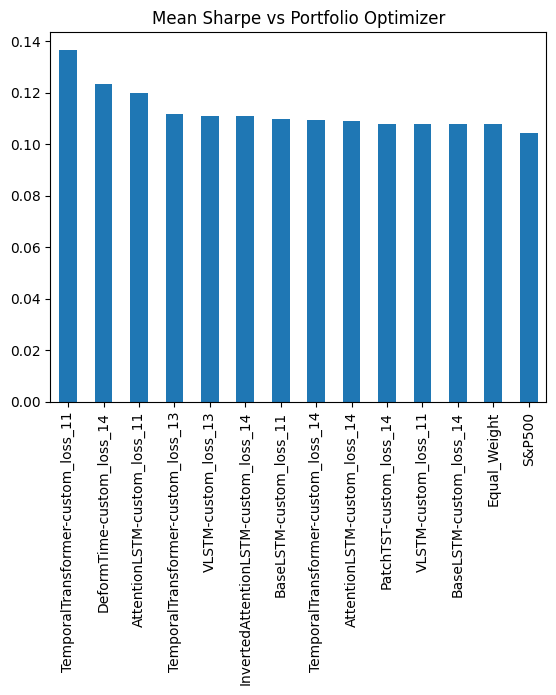

In [6]:

filtered_perf['sharpe'].plot.bar(title='Mean Sharpe vs Portfolio Optimizer')
print('Models/Approaches that BEAT Equal Weight Mean Sharpe:')

In [7]:
print('Models/Approaches that DID NOT BEAT Equal Weight Mean Sharpe:')
no_beat = all_avg_perf.drop(filtered_perf.index, axis=0)
print(f'{len(no_beat)} NN models did not beat Equal Weight Portfolio:')
no_beat

Models/Approaches that DID NOT BEAT Equal Weight Mean Sharpe:
16 NN models did not beat Equal Weight Portfolio:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
DeformTime-custom_loss_10,0.044362,0.080825,0.126800,-0.120688,-0.039663,1.275038,0.020375
DeformTime-custom_loss_11,0.121750,0.105137,0.216938,-0.187150,-0.059487,1.466938,0.032500
DeformTime-custom_loss_13,0.060812,0.089362,0.134900,-0.102975,-0.036937,1.295725,0.018625
TemporalTransformer-custom_loss_10,0.056900,0.102112,0.158887,-0.096875,-0.032975,1.348688,0.021862
PatchTST-custom_loss_10,0.077525,0.086775,0.144450,-0.140662,-0.043950,1.273000,0.015550
PatchTST-custom_loss_11,0.073175,0.101712,0.173038,-0.110225,-0.034537,1.312700,0.021087
PatchTST-custom_loss_13,0.082275,0.099312,0.170387,-0.122725,-0.038600,1.327225,0.021050
BaseLSTM-custom_loss_10,0.076537,0.084200,0.141825,-0.123450,-0.040675,1.293063,0.020312
BaseLSTM-custom_loss_13,0.062675,0.104650,0.161900,-0.100575,-0.033475,1.358237,0.021625
AttentionLSTM-custom_loss_10,0.076700,0.057337,0.119762,-0.186462,-0.057812,1.215438,0.015350


In [8]:
# Split Benchmarks and filtered models

benchmarks_df = all_avg_perf[all_avg_perf.index.isin(all_benches)]
all_avg_perf = all_avg_perf[~all_avg_perf.index.isin(all_benches)]

## Multi Metric Analysis:

### Correlation Analysis

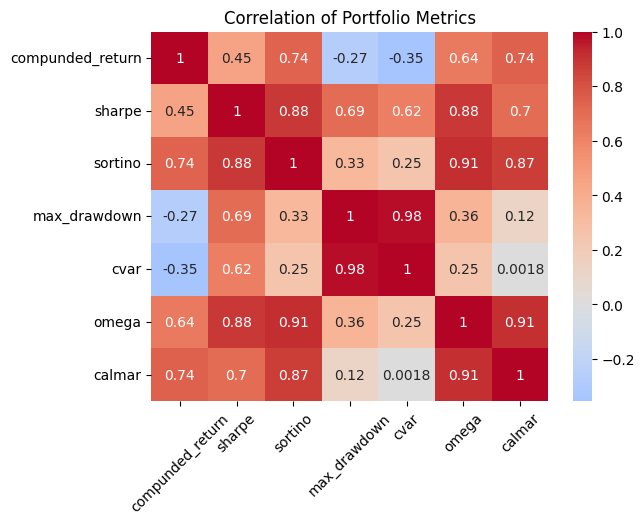


sharpe is highly correlated with:
  sortino: 0.884
  omega: 0.882

sortino is highly correlated with:
  sharpe: 0.884
  omega: 0.914
  calmar: 0.868

max_drawdown is highly correlated with:
  cvar: 0.982

cvar is highly correlated with:
  max_drawdown: 0.982

omega is highly correlated with:
  sharpe: 0.882
  sortino: 0.914
  calmar: 0.906

calmar is highly correlated with:
  sortino: 0.868
  omega: 0.906


In [9]:
corr = all_avg_perf.corr()

plot_corr(corr, title='Correlation of Portfolio Metrics')

high_corr_with_each_metric(corr, threshold=0.75)

Most metrics are highly correlated with each other, with omega and sharpe showing high correlation with most of the other metrics. We can choose Sharpe, Calmar and maybe even CVaR to be our main metrics. CVaR and MDD are highly correlated so we can have one of them to add in loss like or bad scenarios.

##### Principle Component Analysis:

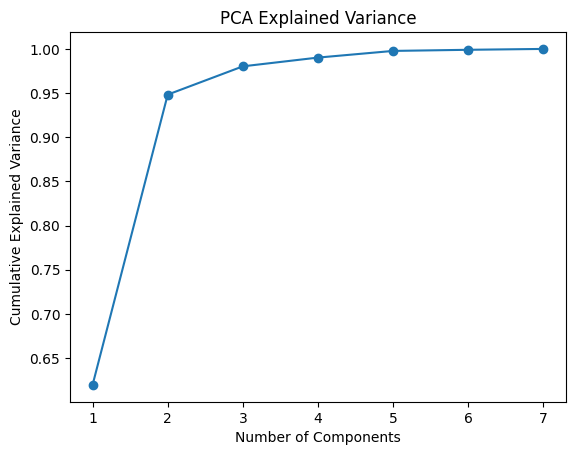

In [10]:
scaler = StandardScaler()
scaled_perf = scaler.fit_transform(all_avg_perf)

pca = PCA()
pca.fit(scaled_perf)

# Explained variance ratio
explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

plt.plot(range(1, len(explained)+1), cumulative, 'o-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

The first principle component explains ~ 25% of the variance. At 6 princple components, almost 100% of the variance is explained.

In [11]:
loadings = pca.components_.T 

def print_important_metrics(loadings, metrics, n_components=5, top_n=3):
    for i in range(n_components):
        # Get loadings for component i
        comp_loadings = loadings[:, i]
        # Sort by absolute value
        sorted_idx = np.argsort(np.abs(comp_loadings))[::-1]
        print(f"\nPrincipal Component {i+1} (explained variance: {pca.explained_variance_ratio_[i]:.3f})")
        for j in range(top_n):
            idx = sorted_idx[j]
            print(f"  {metrics[idx]}: {comp_loadings[idx]:.3f}")

# Example:
print_important_metrics(loadings, all_avg_perf.columns, n_components=6, top_n=3)


Principal Component 1 (explained variance: 0.619)
  sortino: 0.463
  omega: 0.461
  sharpe: 0.459

Principal Component 2 (explained variance: 0.329)
  cvar: 0.599
  max_drawdown: 0.568
  compunded_return: -0.460

Principal Component 3 (explained variance: 0.032)
  compunded_return: 0.640
  calmar: -0.583
  omega: -0.381

Principal Component 4 (explained variance: 0.010)
  omega: 0.629
  calmar: -0.612
  sharpe: 0.309

Principal Component 5 (explained variance: 0.008)
  sortino: 0.803
  compunded_return: -0.449
  max_drawdown: -0.299

Principal Component 6 (explained variance: 0.001)
  cvar: 0.736
  max_drawdown: -0.616
  sortino: -0.163


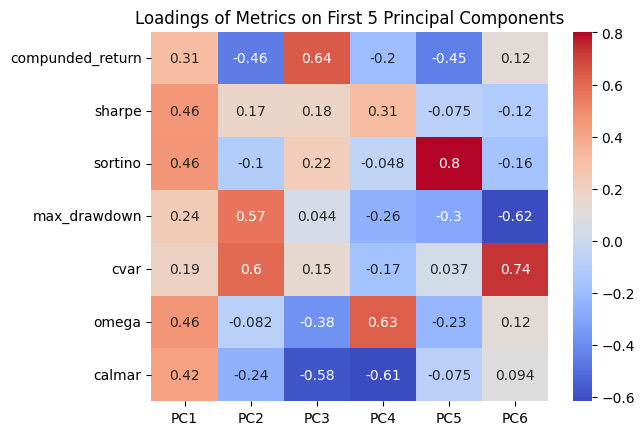

In [12]:
plt.figure()
sns.heatmap(loadings[:, :6], annot=True, cmap='coolwarm', 
            xticklabels=[f'PC{i+1}' for i in range(6)],
            yticklabels=all_avg_perf.columns)
plt.title('Loadings of Metrics on First 5 Principal Components')
plt.show()

PC1 (explains 50.0% of variance) – High positive loadings on Sharpe (0.50), Omega (0.48), and Sortino (0.48).
- PC1 captures risk‑adjusted return (higher is better).
PC2 (explains 27.8% of variance) – High positive loading on CVaR (0.58) (which is undesirable) and negative loadings on Calmar (–0.46) and compounded return (–0.46) (both desirable).
- Higher PC2 indicates higher tail risk, lower drawdown‑adjusted return, and lower raw return – i.e., worse overall.
- To align with “higher is better”, we invert PC2 (use –PC2). Then –PC2 represents low tail risk, high Calmar, and high raw return.
PC3 (explains 12.9% of variance) – High positive loading on compounded return (0.76) but also positive on CVaR (0.33) and negative on Calmar (–0.48). This component is ambiguous (higher raw return comes with higher tail risk and lower Calmar), so we do not use it for Pareto selection.
Thus, we construct a 2D Pareto frontier using PC1 (risk‑adjusted return) and –PC2 (low tail risk + high Calmar/return). Both dimensions are “higher is better”, providing a clear, interpretable trade‑off. This approach leverages the PCA results while avoiding the complexity of a third dimension.

For robustness, we also consider the original metrics Sharpe (primary), Calmar (drawdown control), and CVaR (tail risk) as a sanity check. However, the PC1 + –PC2 combination already captures the same information in a more balanced way.

##### Pareto Frontier with Top 2 Principle Components

In [13]:
# Transform the standardized data (already filtered to models only, no benchmarks)
pca_scores = pca.transform(scaled_perf)   # shape (n_models, n_components)

pc_df = pd.DataFrame({
    'PC1': pca_scores[:, 0],
    'PC2_inv': -pca_scores[:, 1]          # invert so higher is better
}, index=all_avg_perf.index)

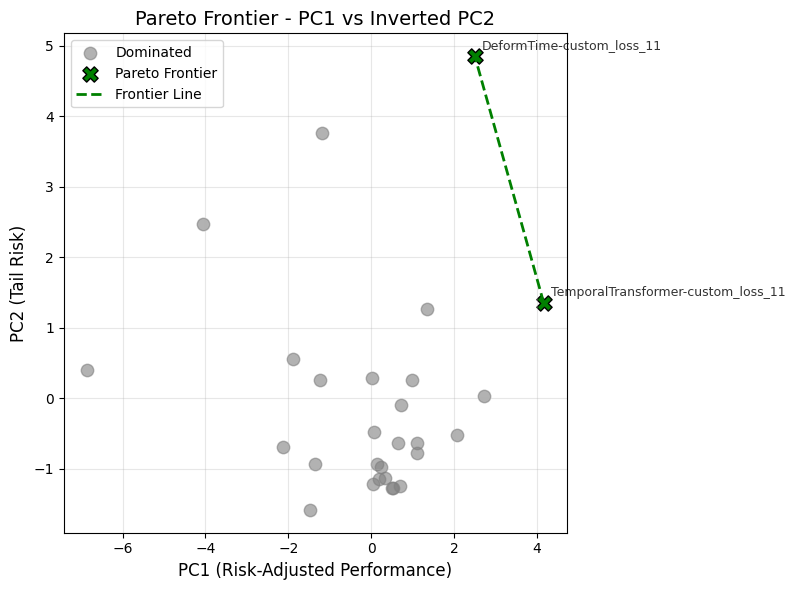

,PC1,PC2_inv,dominated
DeformTime-custom_loss_11,2.503117,4.855823,False
TemporalTransformer-custom_loss_11,4.167632,1.351961,False


In [14]:
pc_df['dominated'] = pareto_dominance(pc_df, ['PC1', 'PC2_inv'])
frontier = pc_df[~pc_df['dominated']].copy()

frontier_sorted = frontier.sort_values('PC1')

fig = plot_2d_pareto(
    df=pc_df,
    x_col='PC1',
    y_col='PC2_inv',
    dominated_col='dominated',
    title='Pareto Frontier - PC1 vs Inverted PC2',
    xlabel='PC1 (Risk-Adjusted Performance)',
    ylabel='PC2 (Tail Risk)'
)
plt.show()
frontier

In [15]:
fig = px.scatter_3d(
    all_avg_perf,
    x='sharpe',
    y='compunded_return',
    z='cvar',
    hover_name=all_avg_perf.index,
    color='sharpe',                # color by Sharpe (or any metric)
    title='3D Pareto Frontier: Sharpe, Calmar, CVaR',
    labels={
        'sharpe': 'Sharpe Ratio',
        'compunded_return': 'Compounded Return',
        'cvar': 'CVaR (higher better)'
    }
)

# Update marker size and appearance
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

In [16]:
temp_avg_perf = all_avg_perf.copy()

cols = ['sharpe', 'compunded_return', 'cvar']
temp_avg_perf['dominated_3d'] = pareto_dominance(temp_avg_perf, cols)

frontier_3d = temp_avg_perf[~temp_avg_perf['dominated_3d']]

fig = plot_3d_pareto(
    df=temp_avg_perf,
    x_col='sharpe',
    y_col='compunded_return',
    z_col='cvar',
    dominated_col='dominated_3d',
    title='3D Pareto Frontier Lower Confidence Bound (Sharpe, Compounded Return, CVaR)',
    x_title='Sharpe Ratio',
    y_title='Compounded Return',
    z_title='CVaR (higher better)'
)

fig.show()

# Efficient frontier models vs Benchmarks
frontier_model_names = list(frontier_3d.index)
pd.concat(
    [frontier_3d.sort_values(by='sharpe', ascending=False), benchmarks_df],
    axis=0
)

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar,dominated_3d
TemporalTransformer-custom_loss_11,0.116925,0.136675,0.213725,-0.107150,-0.038087,1.477050,0.031200,False
DeformTime-custom_loss_14,0.082600,0.123362,0.186925,-0.093062,-0.032987,1.409587,0.024675,False
AttentionLSTM-custom_loss_11,0.086675,0.119913,0.198362,-0.094225,-0.033962,1.414625,0.030087,False
TemporalTransformer-custom_loss_13,0.075537,0.111925,0.174750,-0.100487,-0.032837,1.379350,0.023100,False
VLSTM-custom_loss_13,0.075612,0.111113,0.173775,-0.096287,-0.031837,1.373175,0.023175,False
AttentionLSTM-custom_loss_14,0.056700,0.109262,0.167687,-0.096537,-0.031675,1.381212,0.023050,False
PatchTST-custom_loss_14,0.057100,0.107900,0.164350,-0.095675,-0.031813,1.374525,0.022613,False
BaseLSTM-custom_loss_14,0.057037,0.107737,0.163788,-0.096200,-0.031762,1.373250,0.022613,False
DeformTime-custom_loss_11,0.121750,0.105137,0.216938,-0.187150,-0.059487,1.466938,0.032500,False
VLSTM-custom_loss_14,0.068587,0.103275,0.160600,-0.094337,-0.031725,1.344413,0.020588,False


#### Daily Returns for the frontier models

In [17]:
processed_files = {
    'returns_val': Path(paths_config['processed_paths']['returns_val'])
}

processed_dfs = load_csv_files(processed_files, index_dt=True)

def extract_window_dates(returns_val, num_steps, out_size):
    out_wind_idxs = []
    for step in range(1, num_steps+1):
        current_start, current_end = calc_current_idxs(step, out_size)

        out_wind_idxs.append((current_start, current_end))
    
    out_win_date_cols = get_date_index_col(returns_val, out_wind_idxs)

    return out_win_date_cols


out_win_date_cols = extract_window_dates(processed_dfs['returns_val'], 8, 60)

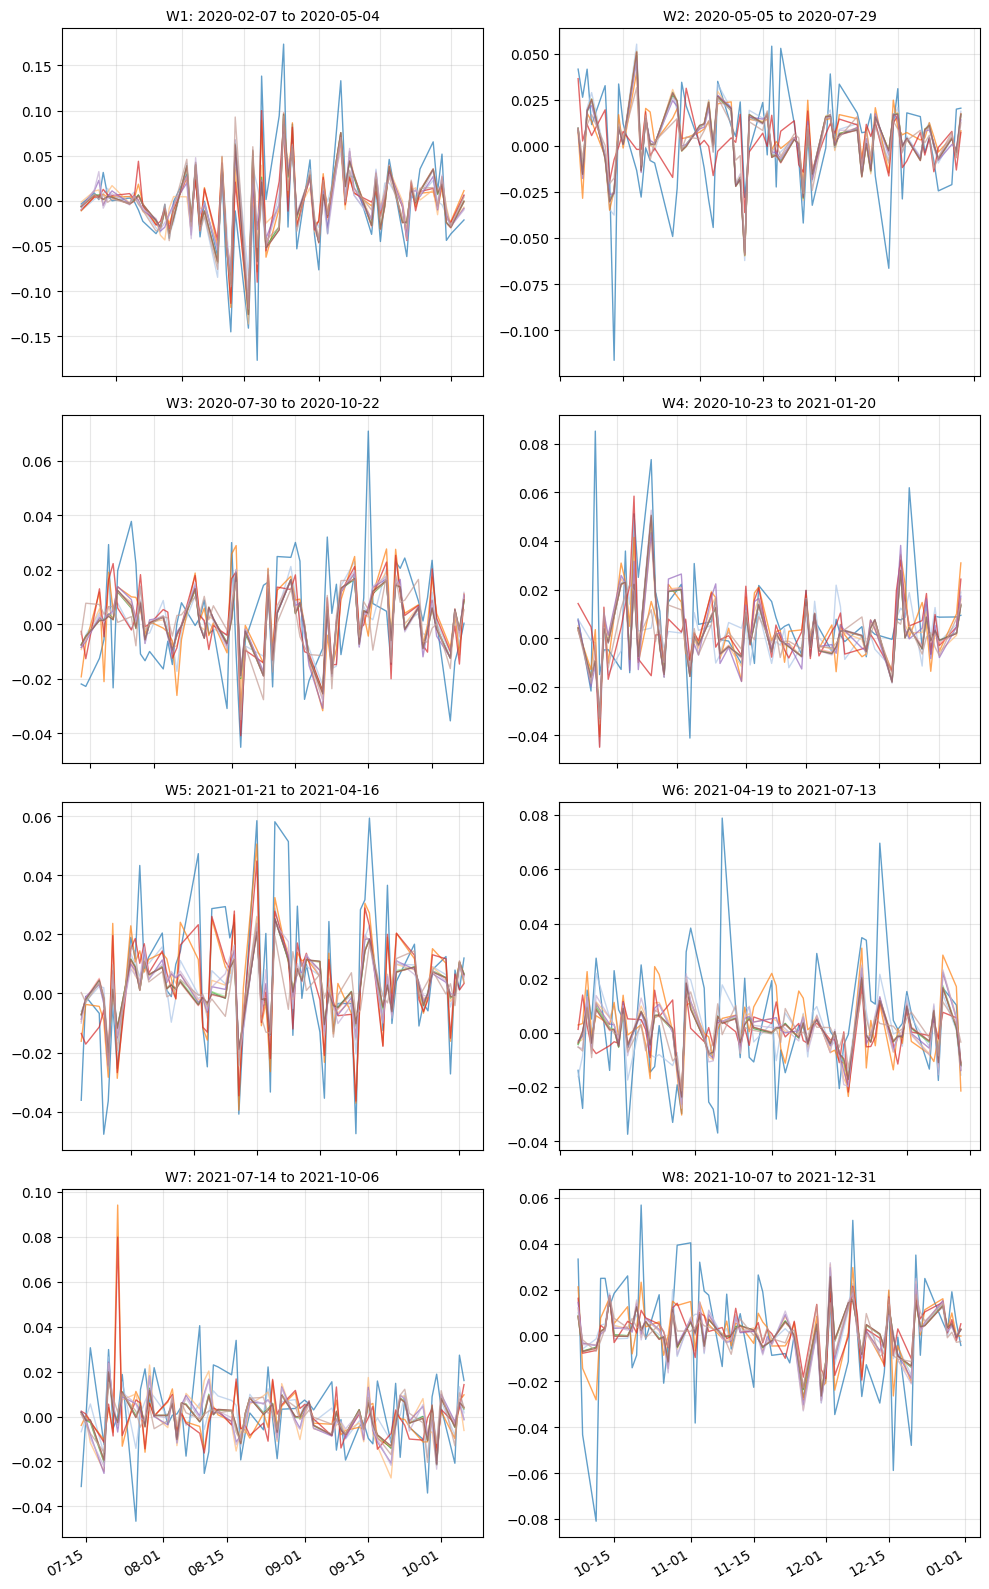

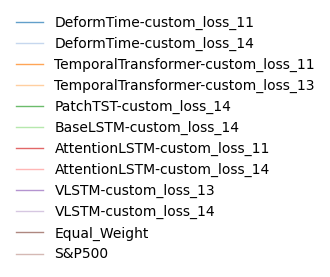

In [18]:
if all_daily_rets:    
    frontier_daily_rets = {
        k: all_daily_rets[k] for k in frontier_model_names if k in frontier_model_names
    }

    for bench in all_benches:
        bench_rets = all_daily_rets.get(bench)
        if bench_rets:
            frontier_daily_rets.update({bench: bench_rets})

    plot_windowed_comparison(
        all_daily_returns=frontier_daily_rets,
        window_dates=out_win_date_cols,
        windows_per_row=2,
        plot=True
    )
else:
    print('WARNING: No daily returns found.')

#### Training Loss Curves for best performing model loss combination

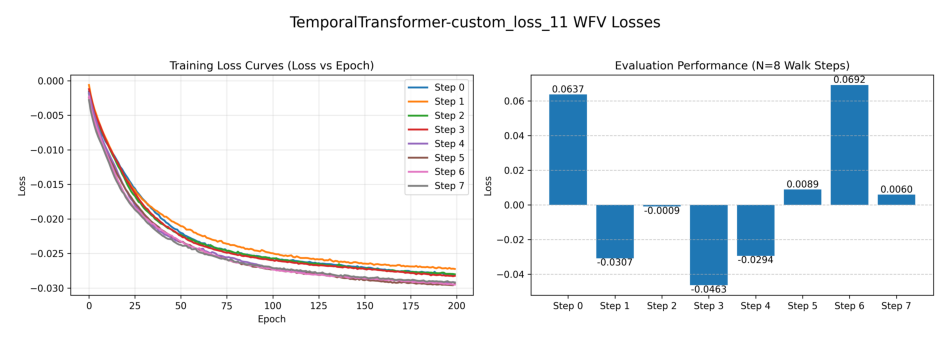

{'model': {'hidden_size': 32,
  'lstm_layers': 1,
  'trans_layers': 1,
  'nheads': 2,
  'dropout': 0.10960857653576966,
  'expansion_factor': 4,
  'equal_prior': False},
 'optimizer': {'lr': 0.00010892235722629424,
  'weight_decay': 0.011286148334326314},
 'train': {'train_batch_size': 64,
  'val_batch_size': 64,
  'clip_grad_norm': 0.5,
  'epochs': 200,
  'min_epochs': 0,
  'early_stopping': False,
  'early_stop_patience': 20,
  'early_stop_min_delta': 0.0001},
 'scheduler': {'factor': 0.5, 'patience': 10, 'min_lr': 1e-08},
 'loss': {'cvar_lambda': 0.001, 'risk_p_lambda': 0.1}}

In [19]:
def plot_train_curves(model_name):
    plt.figure(figsize=(12, 8))
    img = mpimg.imread(artifacts_paths['tuned_plots_dir'] / f'{model_name} WFV Losses.png')
    plt.imshow(img)
    plt.axis('off')  # hide axes
    plt.show()

model_name = 'TemporalTransformer-custom_loss_11'
plot_train_curves(model_name)
opti_hparams.get(model_name)

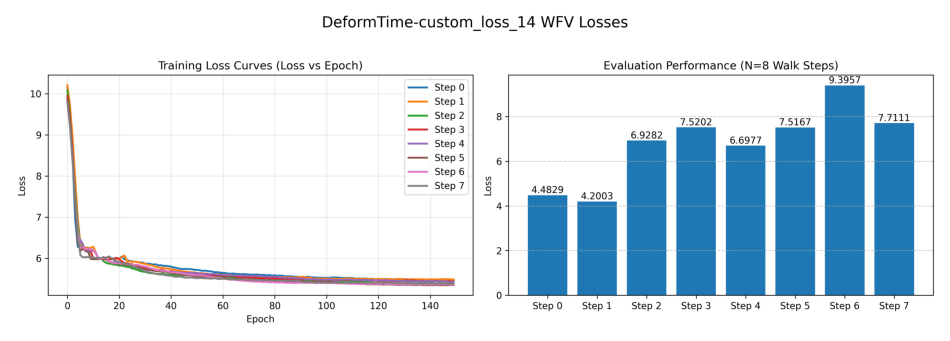

In [20]:
model_name = 'DeformTime-custom_loss_14'
plot_train_curves(model_name)

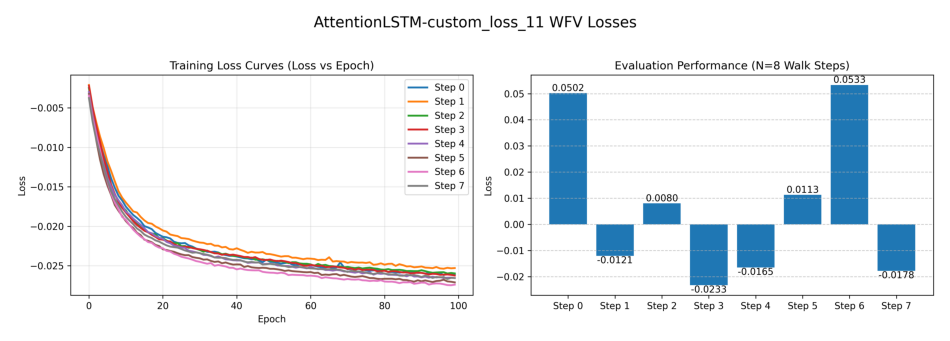

In [21]:
model_name = 'AttentionLSTM-custom_loss_11'
plot_train_curves(model_name)

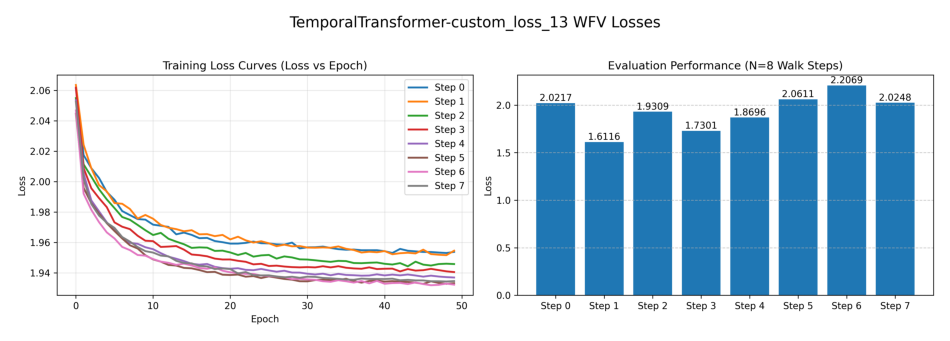

In [22]:
model_name = 'TemporalTransformer-custom_loss_13'
plot_train_curves(model_name)

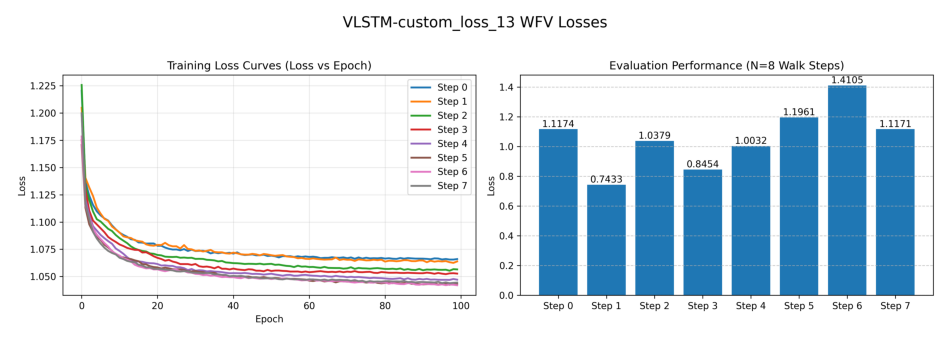

In [23]:
model_name = 'VLSTM-custom_loss_13'
plot_train_curves(model_name)

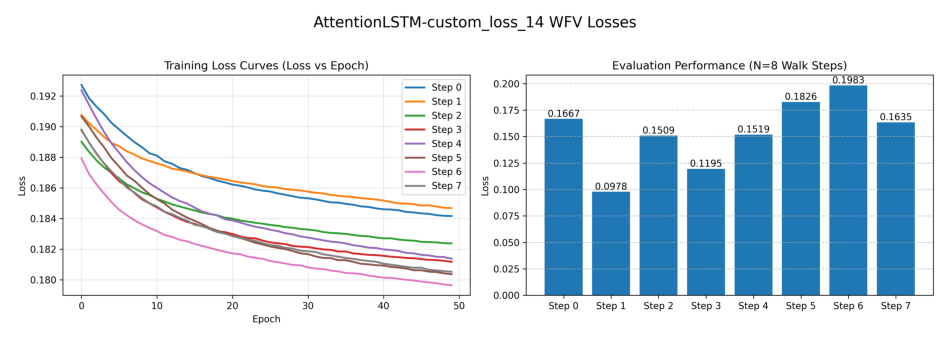

In [24]:
model_name = 'AttentionLSTM-custom_loss_14'
plot_train_curves(model_name)

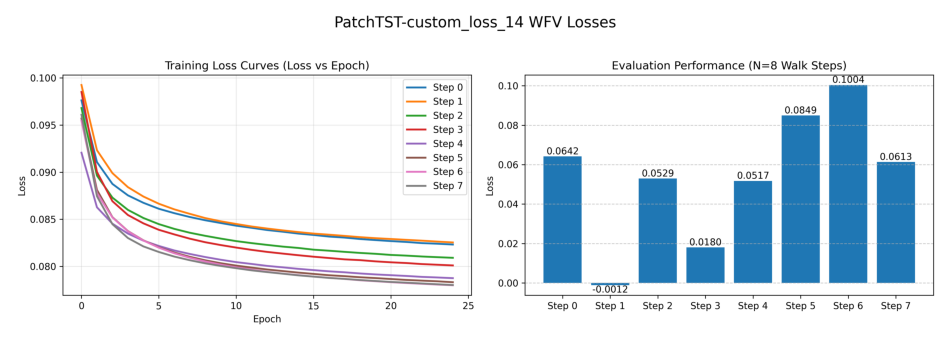

In [25]:
model_name = 'PatchTST-custom_loss_14'
plot_train_curves(model_name)

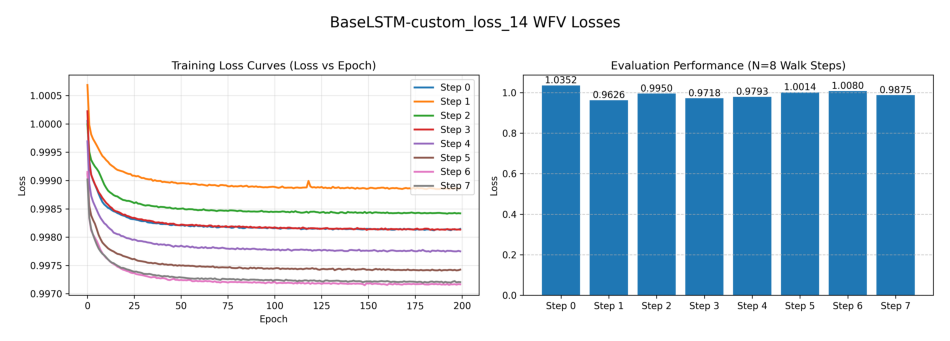

In [26]:
model_name = 'BaseLSTM-custom_loss_14'
plot_train_curves(model_name)

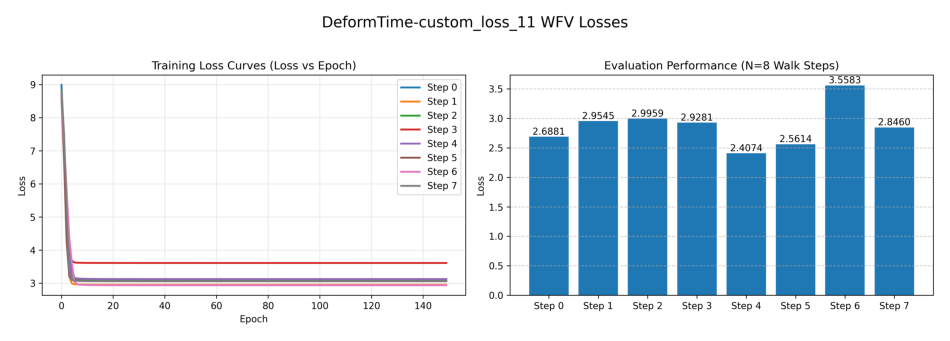

In [27]:
model_name = 'DeformTime-custom_loss_11'
plot_train_curves(model_name)

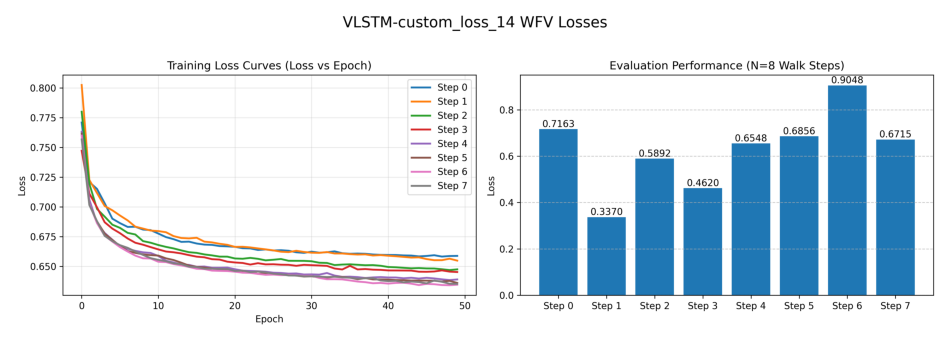

In [28]:
model_name = 'VLSTM-custom_loss_14'
plot_train_curves(model_name)